# Task 9 — Industrial Predictive Maintenance (Industry Level)

**Objectif :** prédire les pannes de fraiseuse industrielle à partir des capteurs, en minimisant les fausses alertes (pas juste l'accuracy globale).

**Dataset :** AI4I 2020 (UCI/Kaggle) — 10 000 lignes, 3.4% de pannes seulement.

In [15]:
# setup
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (classification_report, confusion_matrix, ConfusionMatrixDisplay,
                               precision_recall_curve, f1_score)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (9, 5)

## 1. Chargement des données

In [16]:
df = pd.read_csv("../data/ai4i2020.csv")

# XGBoost n'accepte pas les [ ] dans les noms de colonnes -> on nettoie tout de suite
df.columns = (df.columns.str.replace(r"\s*\[.*?\]", "", regex=True).str.strip())

print(df.shape)
df.head()

(10000, 14)


,UDI,Product ID,Type,Air temperature,Process temperature,Rotational speed,Torque,Tool wear,Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [17]:
print(df.isnull().sum().sum())
df["Machine failure"].value_counts(normalize=True).round(4)

0


Machine failure
0    0.9661
1    0.0339
Name: proportion, dtype: float64

## 2. Déséquilibre des classes — le point de départ de toute la tâche

C:\Users\Administrateur\AppData\Local\Temp\ipykernel_6188\3965531344.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="Machine failure", data=df, palette="rocket", ax=ax)
C:\Users\Administrateur\AppData\Local\Temp\ipykernel_6188\3965531344.py:3: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(["Fonctionnement normal", "Panne"])


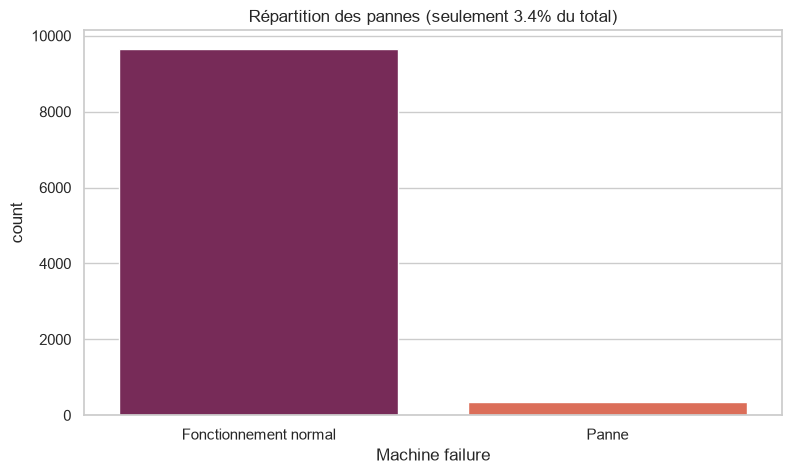

In [18]:
fig, ax = plt.subplots()
sns.countplot(x="Machine failure", data=df, palette="rocket", ax=ax)
ax.set_xticklabels(["Fonctionnement normal", "Panne"])
ax.set_title(f"Répartition des pannes (seulement {df['Machine failure'].mean():.1%} du total)")
plt.savefig("../outputs/01_class_balance.png", dpi=150, bbox_inches="tight")
plt.show()

## 3. Quel type de panne est le plus fréquent ?

C:\Users\Administrateur\AppData\Local\Temp\ipykernel_6188\380555646.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=failure_counts.values, y=failure_counts.index, palette="flare")


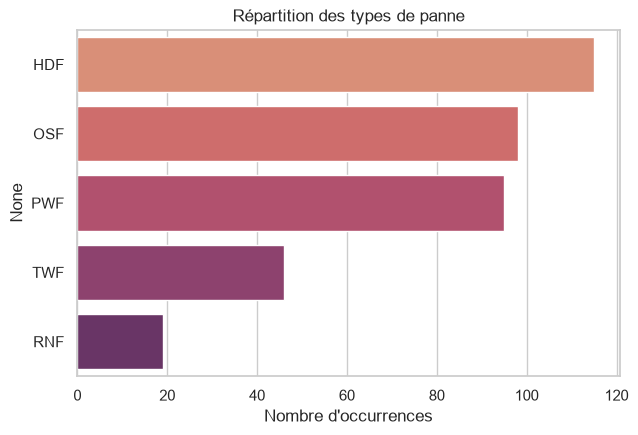

In [19]:
failure_types = ["TWF", "HDF", "PWF", "OSF", "RNF"]
failure_counts = df[failure_types].sum().sort_values(ascending=False)

plt.figure(figsize=(7, 4.5))
sns.barplot(x=failure_counts.values, y=failure_counts.index, palette="flare")
plt.xlabel("Nombre d'occurrences")
plt.title("Répartition des types de panne")
plt.savefig("../outputs/02_failure_types.png", dpi=150, bbox_inches="tight")
plt.show()

## 4. Préparation des données

In [20]:
# UDI et Product ID sont des identifiants, pas des features -> on les enlève
# on enlève aussi les colonnes de détail des pannes (TWF, HDF...) : les utiliser serait de la fuite de données
# (elles ne sont connues qu'APRÈS la panne, pas avant)
df_model = df.drop(columns=["UDI", "Product ID", "TWF", "HDF", "PWF", "OSF", "RNF"])

le_type = LabelEncoder()
df_model["Type"] = le_type.fit_transform(df_model["Type"])

X = df_model.drop(columns=["Machine failure"])
y = df_model["Machine failure"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(X_train.shape, X_test.shape)
print("Taux de panne train/test :", y_train.mean().round(3), y_test.mean().round(3))

(8000, 6) (2000, 6)
Taux de panne train/test : 0.034 0.034


## 5. Modèle de base — Random Forest

In [21]:
rf = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1, class_weight="balanced")
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print(classification_report(y_test, y_pred_rf, target_names=["Normal", "Panne"]))

              precision    recall  f1-score   support

      Normal       0.99      0.99      0.99      1932
       Panne       0.77      0.74      0.75        68

    accuracy                           0.98      2000
   macro avg       0.88      0.86      0.87      2000
weighted avg       0.98      0.98      0.98      2000



## 6. La contrainte industrielle — False Discovery Rate

Le FDR (False Discovery Rate) répond à la question : **parmi toutes les alertes de panne données par le modèle, combien sont de fausses alertes ?** C'est ce qui compte le plus ici — trop de fausses alertes = arrêts de production inutiles et coûteux, même si l'accuracy globale reste bonne.

In [22]:
def false_discovery_rate(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    return fp / (fp + tp) if (fp + tp) > 0 else 0.0

fdr_rf = false_discovery_rate(y_test, y_pred_rf)
print(f"False Discovery Rate (Random Forest) : {fdr_rf:.1%}")
print(f"→ sur toutes les alertes de panne données, {fdr_rf:.1%} sont en réalité de fausses alertes.")

False Discovery Rate (Random Forest) : 23.1%
→ sur toutes les alertes de panne données, 23.1% sont en réalité de fausses alertes.


## 7. Matrice de confusion

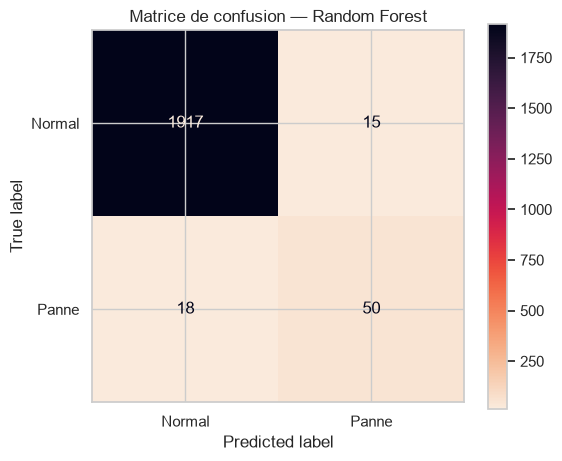

In [23]:
fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred_rf)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Normal", "Panne"])
disp.plot(ax=ax, cmap="rocket_r")
ax.set_title("Matrice de confusion — Random Forest")
plt.savefig("../outputs/03_confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

## 8. Réglage du seuil pour minimiser le FDR

Par défaut, un modèle de classification utilise un seuil de 0.5 pour décider "panne" ou "normal". En le remontant, on rend le modèle plus "exigeant" avant de déclencher une alerte — quitte à accepter de rater quelques pannes (baisse du recall) pour réduire drastiquement les fausses alertes.

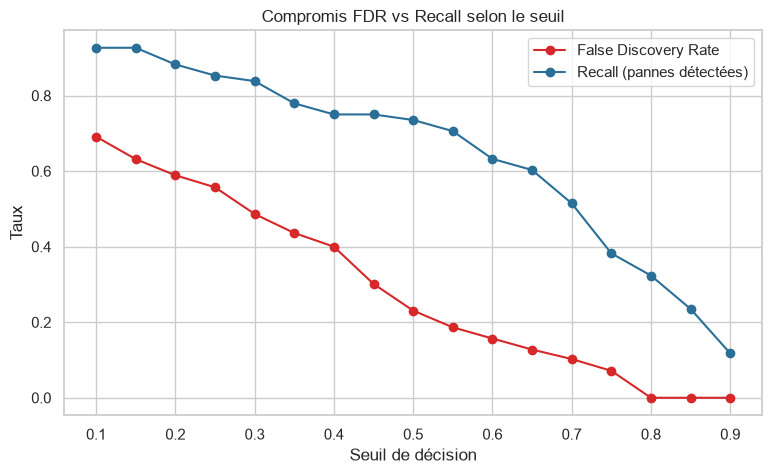

In [27]:
y_proba_rf = rf.predict_proba(X_test)[:, 1]

thresholds = np.arange(0.1, 0.95, 0.05)
fdr_scores, recall_scores, accuracy_scores = [], [], []

from sklearn.metrics import recall_score, accuracy_score

for t in thresholds:
    y_pred_t = (y_proba_rf >= t).astype(int)
    fdr_scores.append(false_discovery_rate(y_test, y_pred_t))
    recall_scores.append(recall_score(y_test, y_pred_t))
    accuracy_scores.append(accuracy_score(y_test, y_pred_t))

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(thresholds, fdr_scores, marker="o", label="False Discovery Rate", color="#d62828")
ax.plot(thresholds, recall_scores, marker="o", label="Recall (pannes détectées)", color="#2a6f97")
ax.set_xlabel("Seuil de décision")
ax.set_ylabel("Taux")
ax.set_title("Compromis FDR vs Recall selon le seuil")
ax.legend()
plt.savefig("../outputs/04_threshold_tradeoff.png", dpi=150, bbox_inches="tight")
plt.show()

→ Ce graphe montre le vrai compromis industriel : monter le seuil réduit les fausses alertes (bien), mais fait aussi rater davantage de vraies pannes (mal). Le bon seuil dépend du coût relatif d'une fausse alerte vs d'une panne non détectée — une décision business, pas juste technique.

## 9. XGBoost avec pondération des classes

In [28]:
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

xgb = XGBClassifier(n_estimators=200, random_state=42, n_jobs=-1, scale_pos_weight=scale_pos_weight, eval_metric="logloss")
xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)

print(classification_report(y_test, y_pred_xgb, target_names=["Normal", "Panne"]))
print(f"False Discovery Rate (XGBoost) : {false_discovery_rate(y_test, y_pred_xgb):.1%}")

              precision    recall  f1-score   support

      Normal       0.99      0.99      0.99      1932
       Panne       0.72      0.78      0.75        68

    accuracy                           0.98      2000
   macro avg       0.85      0.88      0.87      2000
weighted avg       0.98      0.98      0.98      2000

False Discovery Rate (XGBoost) : 28.4%


## 10. Time-to-Failure (régression sur l'usure de l'outil)

Approximation simple : on utilise `Tool wear` comme proxy du temps restant avant panne potentielle (l'usure de l'outil est un facteur connu de défaillance dans ce dataset).

In [29]:
from sklearn.linear_model import LinearRegression

# on entraîne uniquement sur les cas de panne pour estimer le lien usure -> risque
failure_cases = df_model[df_model["Machine failure"] == 1]

X_ttf = failure_cases.drop(columns=["Machine failure", "Tool wear"])
y_ttf = failure_cases["Tool wear"]

ttf_model = LinearRegression()
ttf_model.fit(X_ttf, y_ttf)

print("R² sur les cas de panne :", round(ttf_model.score(X_ttf, y_ttf), 3))
print("→ estimation grossière : usure moyenne au moment de la panne =", y_ttf.mean().round(1), "min")

R² sur les cas de panne : 0.213
→ estimation grossière : usure moyenne au moment de la panne = 143.8 min


## 11. Corrélation : quel capteur est l'indicateur le plus précoce ?

C:\Users\Administrateur\AppData\Local\Temp\ipykernel_6188\3558758090.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=corr_with_failure.values, y=corr_with_failure.index, palette="crest")


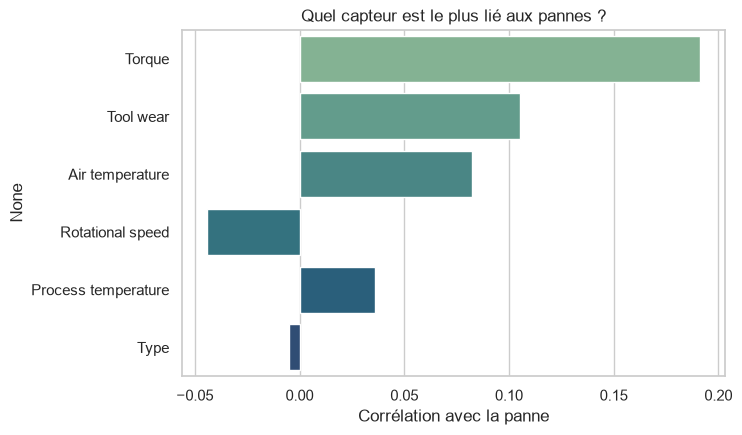

In [30]:
corr_with_failure = df_model.corr(numeric_only=True)["Machine failure"].drop("Machine failure").sort_values(key=abs, ascending=False)

plt.figure(figsize=(7, 4.5))
sns.barplot(x=corr_with_failure.values, y=corr_with_failure.index, palette="crest")
plt.xlabel("Corrélation avec la panne")
plt.title("Quel capteur est le plus lié aux pannes ?")
plt.savefig("../outputs/05_correlation_failure.png", dpi=150, bbox_inches="tight")
plt.show()

**Prochaine étape possible :** un vrai time-to-failure demanderait des données de séries temporelles (mesures répétées sur la même machine avant panne), ce que ce dataset ne fournit pas directement — chaque ligne est une observation indépendante, pas un historique continu.